# Multi-asset risk report

Risk report on one multi-asset book, using data I already had for the DXY and commodities papers: nine Bloomberg commodity TR sub-indices, the S&P 500, five CME currency futures and ICE Dollar Index futures, Dec 2010 to Dec 2025.

What's in here:
1. Data and the book
2. Portfolio construction: 1/N, inverse vol, min variance, risk parity, each with and without a 10% vol target
3. VaR and ES four ways, with a Kupiec backtest
3b. GARCH and DCC-GARCH VaR, and which model passes a bank-style backtest (Kupiec, Christoffersen, Basel traffic light)
4. Which assets carry the risk
5. Historical stress tests
6. One-month loss distribution: Gaussian MC, Student-t MC, block bootstrap
7. Bootstrap CIs on Sharpe
8. FX: dollar beta, hedge ratios, carry vs spot, correlation in stress

Needs the packages in `requirements.txt`. Run All takes about 4 minutes, most of it the rolling DCC refits in 3b.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from risk_engine import data, risk, simulation as sim, portfolio as pf, fx, garch
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30); pd.set_option('display.precision', 4)
R, rf = data.load_panel()
print(R.shape, R.index[0].date(), '->', R.index[-1].date())
R.describe().T[['mean', 'std', 'min', 'max']].assign(ann_vol=lambda x: x['std'] * np.sqrt(252))

(3796, 17) 2010-12-02 -> 2025-12-30


,mean,std,min,max,ann_vol
WTI,4.3876e-05,0.0241,-0.2888,0.2467,0.3833
Brent,2.5243e-04,0.0211,-0.2364,0.1448,0.3355
Gold,3.2351e-04,0.0103,-0.0934,0.0576,0.1627
NatGas,-6.8032e-04,0.0300,-0.1745,0.1812,0.4770
Soybeans,1.8403e-04,0.0124,-0.0674,0.0659,0.1976
Silver,4.1164e-04,0.0195,-0.1771,0.1060,0.3091
Aluminium,2.5824e-05,0.0124,-0.0716,0.0623,0.1976
Corn,-2.7975e-05,0.0152,-0.0762,0.0765,0.2418
Copper,1.8971e-04,0.0147,-0.2203,0.1313,0.2331
BCOMTR,2.1482e-05,0.0090,-0.0512,0.0414,0.1423


## 1. The book
40% equities, 30% commodities (six largest, equal weight), 30% currency futures vs the dollar (equal weight). I rebalance to these weights daily in the risk numbers.

In [2]:
assets = ['SPX', 'WTI', 'Brent', 'Gold', 'NatGas', 'Soybeans', 'Silver', 'EUR', 'GBP', 'CAD', 'JPY', 'CHF']
W = pd.Series({'SPX': 0.40, **{c: 0.05 for c in ['WTI', 'Brent', 'Gold', 'NatGas', 'Soybeans', 'Silver']},
               **{c: 0.06 for c in ['EUR', 'GBP', 'CAD', 'JPY', 'CHF']}})
X = R[assets]
port = X @ W
pd.DataFrame({'Book': risk.summary(port, rf), 'S&P 500': risk.summary(R.SPX, rf), 'BCOMTR': risk.summary(R.BCOMTR, rf)}).T

,CAGR,Volatility,Sharpe (excess),Max drawdown,Worst day,VaR 99% 1d (hist),ES 97.5% 1d (hist),Skew,Excess kurtosis
Book,0.0483,0.1076,0.3570,-0.2711,-0.0656,0.0193,0.0207,-0.6336,8.9814
S&P 500,0.1227,0.1723,0.6735,-0.3392,-0.1198,0.0309,0.0337,-0.3893,13.7823
BCOMTR,-0.0047,0.1423,-0.0646,-0.6402,-0.0512,0.0254,0.0266,-0.3896,2.6581


## 2. Portfolio construction
Each scheme re-estimated monthly on the trailing year, 2 bp per unit of turnover. The vol-target versions scale the book to 10% annual vol, leverage capped at 2x, idle cash earns T-bills.

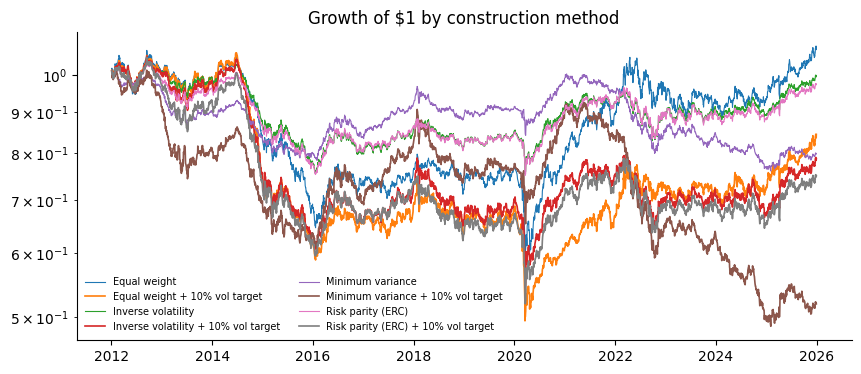

,CAGR,Volatility,Sharpe (excess),Max drawdown,Worst day,VaR 99% 1d (hist),ES 97.5% 1d (hist),Skew,Excess kurtosis
Equal weight,5.9941e-03,0.1076,-0.0364,-0.4455,-0.0504,0.0180,0.0193,-0.3178,3.8092
Equal weight + 10% vol target,-1.2032e-02,0.1050,-0.2121,-0.5365,-0.0576,0.0172,0.0194,-0.6616,6.4321
Inverse volatility,-8.5835e-05,0.0681,-0.1977,-0.2840,-0.0257,0.0108,0.0114,-0.0273,2.1717
Inverse volatility + 10% vol target,-1.6950e-02,0.1034,-0.2652,-0.4857,-0.0540,0.0169,0.0179,-0.2443,3.8025
Minimum variance,-1.5989e-02,0.0540,-0.5613,-0.2490,-0.0175,0.0089,0.0091,0.1451,2.6274
Minimum variance + 10% vol target,-4.5795e-02,0.1015,-0.5654,-0.5227,-0.0354,0.0171,0.0173,0.0723,2.7569
Risk parity (ERC),-1.7717e-03,0.0681,-0.2225,-0.2818,-0.0241,0.0111,0.0113,0.0081,2.3224
Risk parity (ERC) + 10% vol target,-2.0364e-02,0.1046,-0.2942,-0.5072,-0.0505,0.0170,0.0181,-0.2374,3.7323


In [3]:
rows, curves = {}, {}
for s in pf.SCHEMES:
    for vt in [None, 0.10]:
        r, w = pf.backtest(X, s, lookback=252, rebalance='M', cost_bp=2, vol_target=vt, rf=rf)
        name = s + (' + 10% vol target' if vt else '')
        rows[name] = risk.summary(r, rf); curves[name] = (1 + r).cumprod()
tab = pd.DataFrame(rows).T
fig, ax = plt.subplots(figsize=(10, 4))
for k, v in curves.items():
    ax.plot(v.index, v, lw=1.2 if 'target' in k else 0.8, label=k)
ax.set_yscale('log'); ax.set_title('Growth of $1 by construction method'); ax.legend(fontsize=7, ncol=2, frameon=False)
ax.spines[['top', 'right']].set_visible(False); plt.show()
tab

## 3. VaR and expected shortfall
1-day 99% VaR four ways, 97.5% ES (what Basel FRTB uses), and a rolling 500-day backtest with Kupiec's proportion-of-failures test.

In [4]:
m = {'Historical': risk.var_historical(port, .99), 'Normal': risk.var_normal(port, .99),
     'Cornish-Fisher': risk.var_cornish_fisher(port, .99), 'Filtered historical (EWMA)': risk.var_filtered_historical(port, .99)}
es = {'ES 97.5% historical': risk.es_historical(port, .975), 'ES 97.5% normal': risk.es_normal(port, .975)}
display(pd.Series(m, name='1-day 99% VaR (fraction of book)').to_frame().T); display(pd.Series(es).to_frame('value').T)
bt = pd.DataFrame({meth: {k: v for k, v in risk.var_backtest(port, .99, 500, meth).items() if k != 'forecasts'}
                   for meth in ['historical', 'normal', 'cornish_fisher']}).T
bt

,Historical,Normal,Cornish-Fisher,Filtered historical (EWMA)
1-day 99% VaR (fraction of book),0.0193,0.0156,0.0319,0.0152


,ES 97.5% historical,ES 97.5% normal
value,0.0207,0.0156


,breaches,observations,expected_breaches,breach_rate,kupiec_LR,kupiec_p
historical,55.0,3296.0,32.96,0.0167,1.2393e+01,4.3085e-04
normal,78.0,3296.0,32.96,0.0237,4.4925e+01,2.0471e-11
cornish_fisher,33.0,3296.0,32.96,0.0100,4.9014e-05,9.9441e-01


## 3b. Forecasting VaR: GARCH and DCC-GARCH
Eight one-day 99% VaR models, all forecast out of sample: each is estimated on the previous 1,000 days, GARCH refit every 21 days and DCC every 126. Then three checks a bank's model validation team would run:
* **Kupiec**: right number of breaches?
* **Christoffersen independence**: do breaches come in clusters? A model that breaches five days in a row is useless even if the yearly count is fine.
* **Basel traffic light**: share of rolling 250-day windows in the green (0-4 breaches), yellow (5-9) and red (10+) zone.

The "FHS" versions keep the GARCH or DCC volatility but take the tail quantile from the model's own standardised residuals instead of assuming a symmetric t or normal.

In [5]:
F = {m: risk.var_backtest(port, .99, 1000, m)['forecasts'] for m in ['historical', 'normal', 'cornish_fisher', 'filtered_historical']}
F['garch_t'] = garch.garch_var_forecasts(port, .99, 1000, 21, 't')
F['garch_fhs'] = garch.garch_var_forecasts(port, .99, 1000, 21, 't', 'empirical')
F['dcc_garch'], F['dcc_garch_fhs'], dcc_corr = garch.dcc_var_forecasts(X, W, .99, 1000, 126)
cmp_tab = risk.compare_var_models(port, F, .99)
cmp_tab[['breaches', 'expected', 'kupiec_p', 'independence_p', 'cond_coverage_p', 'back_to_back_breaches',
         'share_green', 'share_yellow', 'share_red', 'avg_VaR']]

,breaches,expected,kupiec_p,independence_p,cond_coverage_p,back_to_back_breaches,share_green,share_yellow,share_red,avg_VaR
historical,33,27.96,0.3516,0.0,0.0001,5,0.8009,0.1029,0.0962,0.0186
normal,54,27.96,0.0,0.0,0.0,8,0.5893,0.298,0.1127,0.0154
cornish_fisher,19,27.96,0.0706,0.0002,0.0002,3,0.892,0.108,0.0,0.0272
filtered_historical,28,27.96,0.9939,0.0001,0.0006,4,0.8716,0.1284,0.0,0.0182
garch_t,44,27.96,0.0049,0.0048,0.0004,4,0.636,0.2799,0.084,0.0156
garch_fhs,31,27.96,0.5701,0.0043,0.0144,3,0.8536,0.1464,0.0,0.017
dcc_garch,50,27.96,0.0002,0.0721,0.0002,3,0.5669,0.338,0.095,0.0142
dcc_garch_fhs,30,27.96,0.7016,0.0418,0.117,2,0.819,0.181,0.0,0.0163


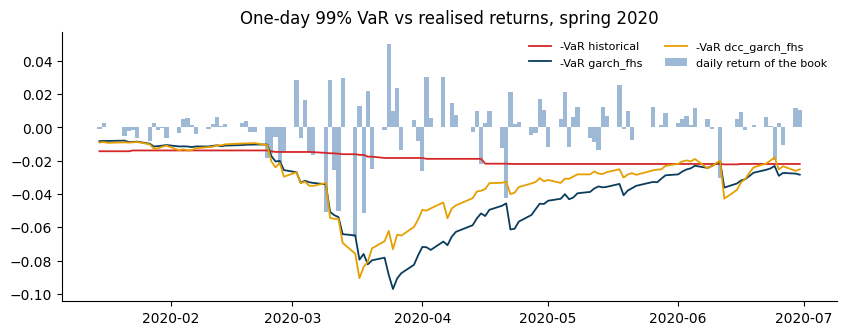

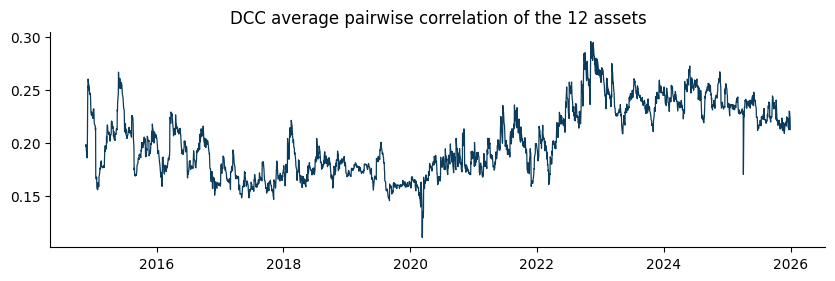

In [6]:
# what the forecasts looked like through COVID
seg = slice('2020-01-15', '2020-06-30')
Fd = pd.DataFrame(F)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(port.loc[seg].index, port.loc[seg], color='#9DB9D5', width=1.0, label='daily return of the book')
for k, c in [('historical', '#D62728'), ('garch_fhs', '#0B3C5D'), ('dcc_garch_fhs', '#E69F00')]:
    ax.plot(Fd.loc[seg].index, -Fd.loc[seg, k], lw=1.3, color=c, label=f'-VaR {k}')
ax.set_title('One-day 99% VaR vs realised returns, spring 2020'); ax.legend(frameon=False, fontsize=8, ncol=2)
ax.spines[['top', 'right']].set_visible(False); plt.show()
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(dcc_corr.index, dcc_corr, color='#0B3C5D', lw=0.9); ax.set_title('DCC average pairwise correlation of the 12 assets')
ax.spines[['top', 'right']].set_visible(False); plt.show()

## 4. Where the risk comes from
Euler split of book vol on the full-sample covariance. I expect the 40% equity sleeve to carry most of it.

Portfolio volatility 10.76%


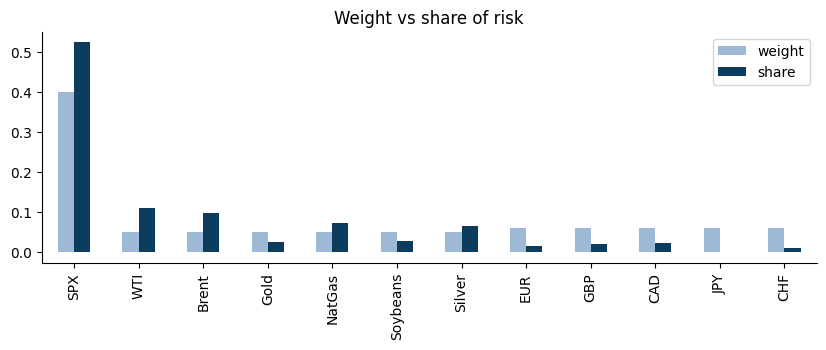

,weight,marginal,contribution,share
SPX,0.40,0.1410,5.6408e-02,5.2420e-01
WTI,0.05,0.2392,1.1958e-02,1.1112e-01
Brent,0.05,0.2109,1.0545e-02,9.7991e-02
Gold,0.05,0.0554,2.7679e-03,2.5722e-02
NatGas,0.05,0.1589,7.9433e-03,7.3817e-02
Soybeans,0.05,0.0637,3.1825e-03,2.9575e-02
Silver,0.05,0.1431,7.1544e-03,6.6485e-02
EUR,0.06,0.0282,1.6922e-03,1.5725e-02
GBP,0.06,0.0371,2.2264e-03,2.0689e-02
CAD,0.06,0.0411,2.4630e-03,2.2889e-02


In [7]:
cov = X.cov().values * 252
rc, vol = risk.risk_contributions(W.values, cov)
rc.index = assets
print(f'Portfolio volatility {vol:.2%}')
ax = rc[['weight', 'share']].plot.bar(figsize=(10, 3), color=['#9DB9D5', '#0B3C5D']); ax.set_title('Weight vs share of risk')
ax.spines[['top', 'right']].set_visible(False); plt.show()
rc

## 5. Historical stress tests

In [8]:
risk.historical_stress(X, W)

,Scenario,Start,End,Days,Portfolio,Worst asset,Best asset
0,Taper tantrum (May-Jun 2013),2013-05-21,2013-06-24,24,-0.0359,Silver (-13.7%),JPY (4.0%)
1,SNB drops EUR/CHF floor (15 Jan 2015),2015-01-15,2015-01-15,1,0.0014,WTI (-4.6%),CHF (17.0%)
2,Oil collapse (Jun 2014 - Feb 2016),2014-06-20,2016-02-11,415,-0.2591,WTI (-79.4%),Gold (-5.6%)
3,Volmageddon (Feb 2018),2018-01-26,2018-02-08,10,-0.0576,NatGas (-12.9%),CHF (0.5%)
4,COVID crash (Feb-Mar 2020),2020-02-19,2020-03-23,24,-0.2279,WTI (-55.5%),JPY (1.1%)
5,WTI below zero (Apr 2020),2020-04-14,2020-04-21,6,-0.0544,WTI (-43.9%),NatGas (4.3%)
6,Inflation and rate shock (2022),2022-01-03,2022-10-12,196,-0.0784,SPX (-24.9%),NatGas (78.1%)
7,Russia invades Ukraine (Feb-Mar 2022),2022-02-23,2022-03-08,10,0.0241,EUR (-3.8%),Brent (36.3%)


## 6. One-month loss distribution: Monte Carlo vs block bootstrap
Same 21-day horizon, three generators. The bootstrap keeps fat tails and vol clustering with no distribution assumed. Gaussian is the baseline and usually understates the tail.

,Mean horizon return,Median horizon return,P(loss),VaR 95%,ES 95%,VaR 99%,ES 99%,P(drawdown > 5%),P(drawdown > 10%),P(drawdown > 20%)
Gaussian MC,0.0050,0.0046,0.4406,0.0456,0.0573,0.0642,0.0738,0.0953,0.0002,0.0000
Student-t MC,0.0050,0.0047,0.4384,0.0452,0.0580,0.0655,0.0766,0.0878,0.0008,0.0000
Block bootstrap (21d blocks),0.0047,0.0064,0.4012,0.0428,0.0657,0.0742,0.1112,0.0989,0.0076,0.0005


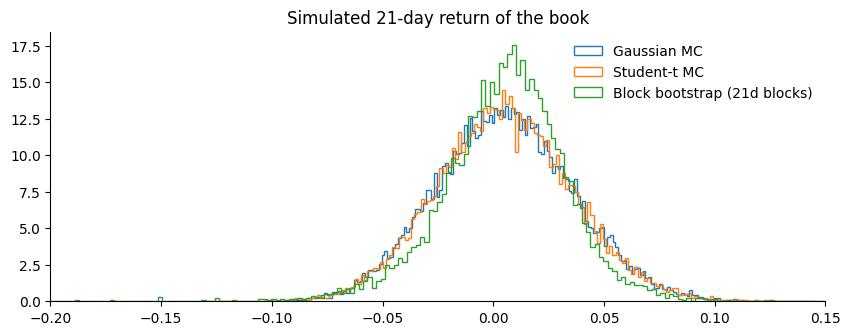

In [9]:
gens = {'Gaussian MC': sim.mc_gaussian(X.values, 20000, 21, seed=1),
        'Student-t MC': sim.mc_student_t(X.values, 20000, 21, seed=1),
        'Block bootstrap (21d blocks)': sim.block_bootstrap(X.values, 20000, 21, 21, seed=1)}
out, ends = {}, {}
for k, S in gens.items():
    p = sim.portfolio_paths(S, W.values); out[k] = sim.horizon_risk(p); ends[k] = p[:, -1] - 1
display(pd.DataFrame(out).T)
fig, ax = plt.subplots(figsize=(10, 3.5))
for k, e in ends.items():
    ax.hist(e, bins=200, histtype='step', density=True, label=k)
ax.set_xlim(-0.2, 0.15); ax.set_title('Simulated 21-day return of the book'); ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False); plt.show()

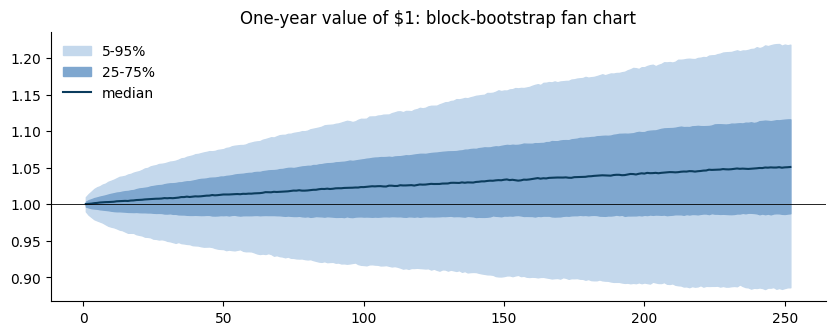

In [10]:
# Fan chart, one year of block-bootstrap paths
S = sim.block_bootstrap(X.values, 5000, 252, 21, seed=7)
P = sim.portfolio_paths(S, W.values)
q = np.quantile(P, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(10, 3.5)); d = np.arange(1, 253)
ax.fill_between(d, q[0], q[4], color='#C4D8EC', label='5-95%'); ax.fill_between(d, q[1], q[3], color='#7FA7CF', label='25-75%')
ax.plot(d, q[2], color='#0B3C5D', label='median'); ax.axhline(1, color='black', lw=0.6)
ax.set_title('One-year value of $1: block-bootstrap fan chart'); ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False); plt.show()

## 7. How sure am I of a Sharpe ratio?
Block-bootstrap 95% intervals. If the interval includes zero, the backtest can't tell the strategy apart from no skill.

In [11]:
ci = {}
for name, r in {'Book': port, 'Risk parity': pf.backtest(X, 'Risk parity (ERC)', rf=rf)[0], 'S&P 500': R.SPX, 'BCOMTR': R.BCOMTR}.items():
    est, lo, hi, _ = sim.bootstrap_ci(r.values, sim.sharpe, n_boot=2000, mean_block=21, seed=3)
    ci[name] = {'Sharpe': est, '95% low': lo, '95% high': hi}
pd.DataFrame(ci).T

,Sharpe,95% low,95% high
Book,0.4926,0.0274,0.9953
Risk parity,0.0080,-0.4775,0.5463
S&P 500,0.7582,0.3237,1.2674
BCOMTR,0.0381,-0.4835,0.5479


## 8. FX
(a) Rolling 6-month beta of each asset to DX futures. (b) Min-variance hedge ratio of each currency against DX. (c) Carry vs spot in the currency futures returns. (d) Does diversification hold up in stress?

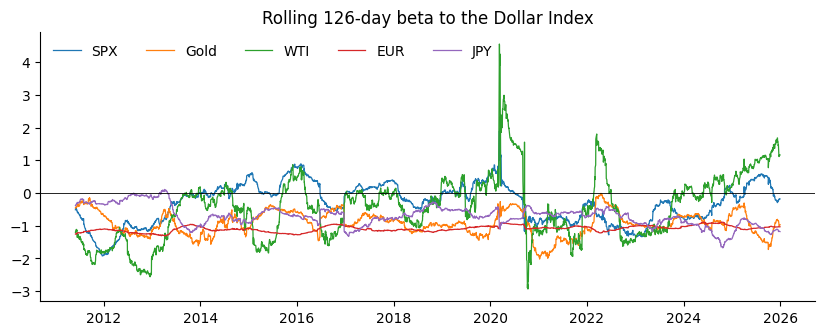

Book beta to the dollar: -0.61


,SPX,WTI,Brent,Gold,NatGas,Soybeans,Silver,EUR,GBP,CAD,JPY,CHF
full-sample beta to DXY,-0.3956,-0.5449,-0.4632,-0.8516,-0.1837,-0.3796,-1.4719,-1.0974,-0.8972,-0.5834,-0.6872,-0.9628


,hedge ratio vs DXY,variance reduction
EUR,-1.0974,0.9143
GBP,-0.8972,0.5231
CAD,-0.5834,0.3299
JPY,-0.6872,0.2784
CHF,-0.9628,0.4643
Gold,-0.8516,0.1360
SPX,-0.3956,0.0262


In [12]:
beta = fx.dollar_exposure(R[assets + ['DXY']], 'DXY', 126)
full = pd.Series({c: risk.beta(R[c], R.DXY) for c in assets}, name='full-sample beta to DXY')
fig, ax = plt.subplots(figsize=(10, 3.5))
for c in ['SPX', 'Gold', 'WTI', 'EUR', 'JPY']:
    ax.plot(beta.index, beta[c], lw=0.9, label=c)
ax.axhline(0, color='black', lw=0.6); ax.set_title('Rolling 126-day beta to the Dollar Index'); ax.legend(frameon=False, ncol=5)
ax.spines[['top', 'right']].set_visible(False); plt.show()
book_beta = risk.beta(port, R.DXY)
h = {c: fx.min_variance_hedge(R[c], R.DXY) for c in ['EUR', 'GBP', 'CAD', 'JPY', 'CHF', 'Gold', 'SPX']}
print(f'Book beta to the dollar: {book_beta:.2f}')
display(full.to_frame().T)
pd.DataFrame(h, index=['hedge ratio vs DXY', 'variance reduction']).T

In [13]:
summ, _ = fx.carry_attribution(R[['EUR', 'GBP', 'CAD', 'JPY', 'CHF']], data.interest_differentials())
display(summ)
cr = fx.correlation_regimes(X, 'SPX')
print(f"Average pairwise correlation: calm {cr['calm']:.2f} vs stressed {cr['stressed']:.2f} (stress = top 20% of trailing S&P 500 volatility)")

,Total return (ann.),Carry component (ann.),Spot and other (ann.),Total vol (ann.)
EUR,-0.0191,-0.0099,-0.0093,0.0809
GBP,-0.0102,-0.0016,-0.0086,0.0874
CAD,-0.0142,-0.0011,-0.0131,0.0716
JPY,-0.0560,-0.0147,-0.0413,0.0918
CHF,-0.0005,-0.0181,0.0176,0.0996


Average pairwise correlation: calm 0.19 vs stressed 0.25 (stress = top 20% of trailing S&P 500 volatility)


## Notes
* All the math lives in `risk_engine/` with its own tests. This notebook only calls it.
* Gaussian MC, Student-t MC (sample or EWMA cov) and the block bootstrap all return the same shape, so sections 6 and 7 reuse one set of functions.
* VaR / ES four ways + Kupiec, Euler risk split, historical stress tests.
* GARCH(1,1)-t and DCC(1,1) written from scratch with scipy, backtested out of sample with Kupiec, Christoffersen and the Basel traffic light.
* Construction: 1/N, inverse vol, min variance, risk parity, with vol targeting and costs.
* FX: dollar beta, min-variance hedge ratios, carry vs spot, correlation in stress.

Next: pull SPXT (S&P total return) and a bond future from Bloomberg; expected shortfall backtest (Acerbi-Szekely); factor model (dollar, carry, momentum, equity beta) for attribution; hook the engine into the SQL database and dashboard.